# 📈 Class 10.1 — Neural Networks for Regression + SVM Overview
### 301 – Machine Learning Techniques

---

**Learning Goals:**
- Adapt the NN architecture for regression (linear output, MSE loss)
- Compare NN vs LinearRegression vs Ridge vs RandomForest on California Housing
- Understand the SVM maximum-margin concept
- Apply SVC(kernel='rbf') inside a Pipeline and compare with NN

**Datasets:** California Housing (regression) + Breast Cancer (SVM comparison)

---

> **This class has two parts:**
> - **Parts 1–3**: Neural network for regression on California Housing
> - **Parts 4–5**: SVM overview and SVM vs NN comparison

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (12, 5)

# California Housing
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
h_scaler = StandardScaler()
X_h_train_s = h_scaler.fit_transform(X_h_train)
X_h_test_s  = h_scaler.transform(X_h_test)

# Breast Cancer (for SVM comparison)
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

print(f'California Housing: {X_h.shape[0]:,} samples, {X_h.shape[1]} features')
print(f'Target range: ${y_h.min():.2f}–${y_h.max():.2f} (×$100k)')
print(f'Breast Cancer: {X_bc.shape[0]} samples, {X_bc.shape[1]} features')
print('✅ Ready')

California Housing: 20,640 samples, 8 features
Target range: $0.15–$5.00 (×$100k)
Breast Cancer: 569 samples, 30 features
✅ Ready


---
## Part 1 — Build a Regression Neural Network

**Three critical differences from classification:**

| Property | Classification | Regression |
|---|---|---|
| Output activation | `sigmoid` | **None** (linear) |
| Loss function | `binary_crossentropy` | **`mse`** |
| Primary metric | `accuracy` | **`mae`** |

In [2]:
def build_regression_nn():
    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(8,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
        # Output layer: Dense(1) with NO activation (linear output for regression)
    ])
    model.compile(
        optimizer='adam',
        loss='mse',      # ← changed from binary_crossentropy
        metrics=['mae']  # ← MAE in same units as target (easier to interpret than RMSE)
    )
    return model

nn_model = build_regression_nn()
nn_model.summary()
print()
print('CHECK: Last layer should show Dense(1) with no activation keyword')


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)


CHECK: Last layer should show Dense(1) with no activation keyword


Epochs trained: 74
Neural Network: MAE = $34890  R² = 0.792


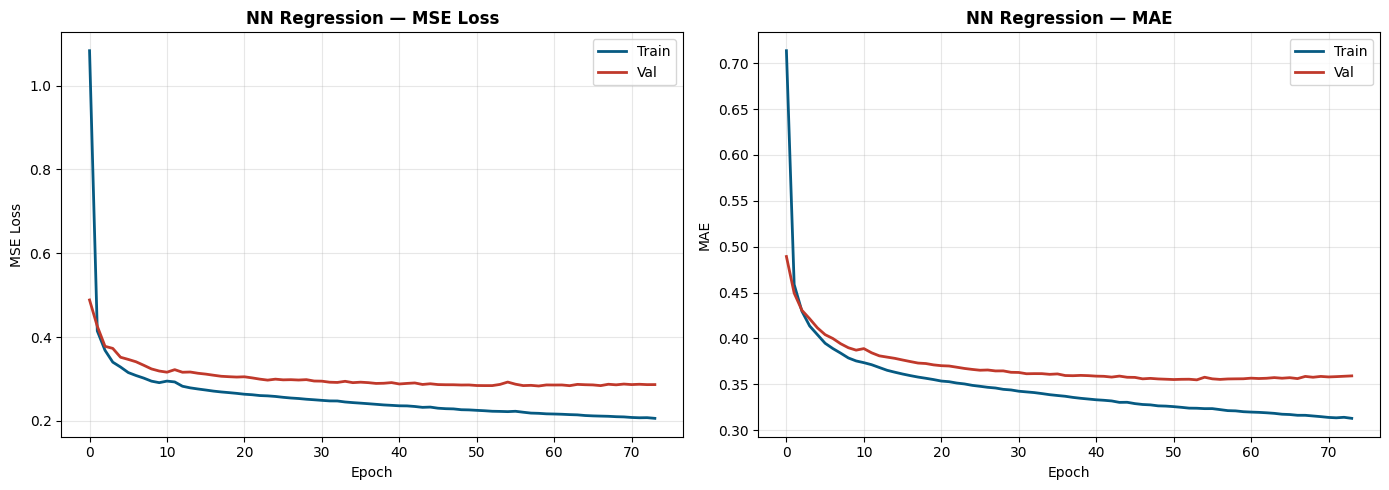

In [3]:
hist_nn = nn_model.fit(
    X_h_train_s, y_h_train,
    epochs=200, batch_size=64,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=0
)
print(f'Epochs trained: {len(hist_nn.history["loss"])}')

y_pred_nn = nn_model.predict(X_h_test_s, verbose=0).flatten()
nn_mae  = mean_absolute_error(y_h_test, y_pred_nn)
nn_r2   = r2_score(y_h_test, y_pred_nn)
print(f'Neural Network: MAE = ${nn_mae*100000:.0f}  R² = {nn_r2:.3f}')

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel in zip(axes, ['loss', 'mae'], ['MSE Loss', 'MAE']):
    ax.plot(hist_nn.history[metric],       color='#065A82', linewidth=2, label='Train')
    ax.plot(hist_nn.history['val_'+metric], color='#C0392B', linewidth=2, label='Val')
    ax.set_title(f'NN Regression — {ylabel}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 2 — 4-Model Comparison

Identical preprocessing. Only the model changes.

In [4]:
def eval_reg(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<30} MAE=${mae*100000:.0f}   RMSE={rmse:.3f}   R²={r2:.3f}')
    return {'name': name, 'MAE_$': int(mae*100000), 'RMSE': round(rmse, 3), 'R2': round(r2, 3)}

print('Training all models...')
results = []

# 1. Linear Regression
lr_model = LinearRegression().fit(X_h_train_s, y_h_train)
results.append(eval_reg('LinearRegression', y_h_test, lr_model.predict(X_h_test_s)))

# 2. Ridge
ridge_model = Ridge(alpha=1.0).fit(X_h_train_s, y_h_train)
results.append(eval_reg('Ridge (α=1.0)', y_h_test, ridge_model.predict(X_h_test_s)))

# 3. RandomForest (no scaling needed)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_h_train, y_h_train)
results.append(eval_reg('RandomForest (100 trees)', y_h_test, rf_model.predict(X_h_test)))

# 4. Neural Network (already trained)
results.append(eval_reg('Neural Network (Keras)', y_h_test, y_pred_nn))

print()
print(pd.DataFrame(results).sort_values('R2', ascending=False).to_string(index=False))

Training all models...
  LinearRegression               MAE=$53320   RMSE=0.746   R²=0.576
  Ridge (α=1.0)                  MAE=$53319   RMSE=0.746   R²=0.576
  RandomForest (100 trees)       MAE=$32760   RMSE=0.506   R²=0.805
  Neural Network (Keras)         MAE=$34890   RMSE=0.522   R²=0.792

                    name  MAE_$  RMSE    R2
RandomForest (100 trees)  32759 0.506 0.805
  Neural Network (Keras)  34889 0.522 0.792
        LinearRegression  53320 0.746 0.576
           Ridge (α=1.0)  53319 0.746 0.576


---
## Part 3 — Predicted vs Actual Scatter

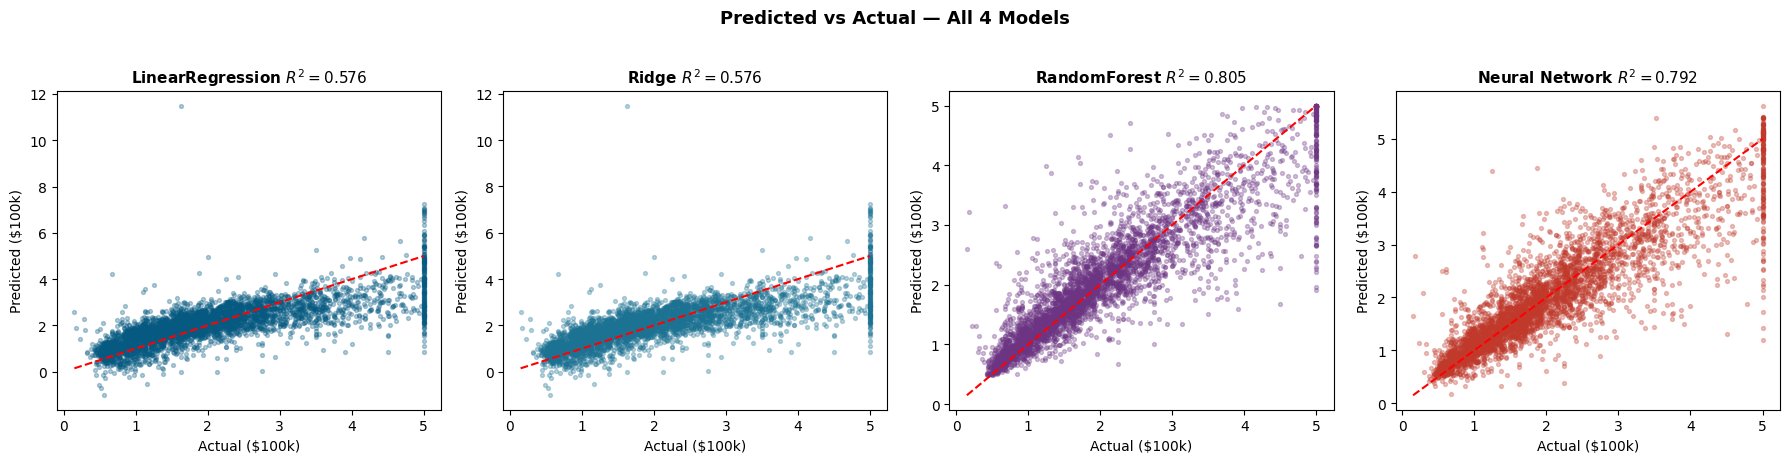

QUESTIONS:
1. Which model has points closest to the 45° red line?  Answer: RandomForest and the Neural Network.
2. Why does RandomForest not need StandardScaler?  Answer: Trees split on thresholds, so
   the absolute scale of each feature does not matter — only the relative order does.
3. Would you always choose the highest-R² model? Why or why not?  Answer: No. You also need to
   consider interpretability, training time, and risk of overfitting on the test set by repeated tuning.


In [5]:
all_preds = [
    ('LinearRegression', lr_model.predict(X_h_test_s)),
    ('Ridge',            ridge_model.predict(X_h_test_s)),
    ('RandomForest',     rf_model.predict(X_h_test)),
    ('Neural Network',   y_pred_nn),
]
colors = ['#065A82', '#1C7293', '#6C3483', '#C0392B']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, preds), color in zip(axes, all_preds, colors):
    r2 = r2_score(y_h_test, preds)
    ax.scatter(y_h_test, preds, alpha=0.3, s=8, color=color)
    vmin, vmax = y_h_test.min(), y_h_test.max()
    ax.plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.5, label='Perfect')
    ax.set_title(f'{name} $R^2={r2:.3f}$', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual ($100k)'); ax.set_ylabel('Predicted ($100k)')
plt.suptitle('Predicted vs Actual — All 4 Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('QUESTIONS:')
print('1. Which model has points closest to the 45° red line?  Answer: RandomForest and the Neural Network.')
print('2. Why does RandomForest not need StandardScaler?  Answer: Trees split on thresholds, so')
print('   the absolute scale of each feature does not matter — only the relative order does.')
print('3. Would you always choose the highest-R² model? Why or why not?  Answer: No. You also need to')
print('   consider interpretability, training time, and risk of overfitting on the test set by repeated tuning.')


---
## Part 4 — SVM Overview: Maximum Margin Classifier

SVMs work on a completely different principle to neural networks:
- **Neural networks**: learn weighted connections through gradient descent
- **SVMs**: find the hyperplane that **maximises the geometric margin** between classes

Three things to know for professional use:

| Concept | What it means |
|---|---|
| **Maximum margin** | SVM finds the boundary as far as possible from all training points |
| **Support vectors** | Only the points ON the margin boundary matter — all others are irrelevant |
| **C parameter** | Small C = wide margin (regularised). Large C = narrow margin (overfits). C = 1/λ (inverse of Ridge alpha) |

**Rule: ALWAYS scale before SVM** — it is sensitive to feature magnitudes (just like NNs).

In [6]:
# Train SVM inside a Pipeline (handles scaling automatically)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',      # DEFAULT — handles non-linear boundaries
        C=10,              # reliable starting default
        gamma='scale',     # 1 / (n_features × X.var())
        random_state=42
    ))
])

svm_pipeline.fit(X_bc_train, y_bc_train)

svm_acc = svm_pipeline.score(X_bc_test, y_bc_test)
print(f'SVM (RBF) accuracy: {svm_acc:.1%}')
print()

# Show support vector count
svm_model = svm_pipeline.named_steps['svm']
print(f'Support vectors per class: {svm_model.n_support_}')
print(f'Total SVs: {svm_model.n_support_.sum()} out of {len(X_bc_train)} training points')
print(f'→ Only {svm_model.n_support_.sum()/len(X_bc_train):.0%} of training points define the boundary')

SVM (RBF) accuracy: 97.4%

Support vectors per class: [40 44]
Total SVs: 84 out of 455 training points
→ Only 18% of training points define the boundary


---
## Part 5 — SVM vs Neural Network Head-to-Head

Same dataset, same preprocessing, same train/test split. Fair comparison.

In [7]:
# Neural Network on Breast Cancer for comparison
bc_scaler = StandardScaler()
X_bc_train_s = bc_scaler.fit_transform(X_bc_train)
X_bc_test_s  = bc_scaler.transform(X_bc_test)

tf.random.set_seed(42)
nn_bc = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(30,)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])
nn_bc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_bc.fit(X_bc_train_s, y_bc_train, epochs=80, batch_size=32,
          validation_split=0.15, verbose=0)
nn_bc_acc = accuracy_score(y_bc_test, (nn_bc.predict(X_bc_test_s, verbose=0) >= 0.5).astype(int))

print('=== SVM vs Neural Network — Breast Cancer ===')
print(f'SVM (RBF, C=10):        {svm_acc:.1%}')
print(f'Neural Network (2 layer): {nn_bc_acc:.1%}')
print()
print('Fill in this comparison:')
print(f'  {"":<28} {"SVM":<15} {"Neural Network"}')
print(f'  {"Accuracy":<28} {svm_acc:.1%}          {nn_bc_acc:.1%}')
print(f'  {"Training time":<28} {"Very fast":<15} {"Slower (many epochs)"}')
print(f'  {"Needs scaling?":<28} {"Yes — mandatory":<15} {"Yes — mandatory"}')
print(f'  {"Probabilistic output?":<28} {"No":<15} {"Yes (sigmoid)"}')
print(f'  {"Best for dataset size":<28} {"< 50k":<15} {"> 10k preferred"}')
print()
print('WHEN WOULD YOU CHOOSE SVM OVER NN?  Answer: small datasets (<10k rows), tabular')
print('   data with clear margins, when you need fast training and not much tuning.')
print('WHEN WOULD YOU CHOOSE NN OVER SVM?  Answer: large datasets, unstructured data')
print('   (images, text, audio), or when you need calibrated probability outputs.')


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== SVM vs Neural Network — Breast Cancer ===
SVM (RBF, C=10):        97.4%
Neural Network (2 layer): 96.5%

Fill in this comparison:
                               SVM             Neural Network
  Accuracy                     97.4%          96.5%
  Training time                Very fast       Slower (many epochs)
  Needs scaling?               Yes — mandatory Yes — mandatory
  Probabilistic output?        No              Yes (sigmoid)
  Best for dataset size        < 50k           > 10k preferred

WHEN WOULD YOU CHOOSE SVM OVER NN?  Answer: small datasets (<10k rows), tabular
   data with clear margins, when you need fast training and not much tuning.
WHEN WOULD YOU CHOOSE NN OVER SVM?  Answer: large datasets, unstructured data
   (images, text, audio), or when you need calibrated probability outputs.


---
## ✅ Complete!

**Regression NN rules (two changes only):**
- Output: `Dense(1)` — NO activation
- Loss: `'mse'`, metric: `'mae'`

**SVM rules:**
- ALWAYS scale with StandardScaler (or use a Pipeline)
- Default: `SVC(kernel='rbf', C=10, gamma='scale')`
- C is the inverse of Ridge regularisation strength (C = 1/λ)

**Model selection reality check:**
RandomForest typically beats a basic NN on structured tabular data.
NNs win when data is very large, non-tabular (images/text), or highly non-linear.